# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

In [20]:
!pip install pandas numpy


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python3 -m pip install --upgrade pip


# 3. Homework - work with your own data

In [21]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [22]:
import pandas as pd
import numpy as np

# --------------------------
# Step 0: Generate synthetic purchase orders dataset
# --------------------------
np.random.seed(42)
n = 100

df = pd.DataFrame({
    "Purchase Order ID": [f"PO{1000+i}" for i in range(n)],
    "Supplier Name": np.random.choice(["Supplier A", "Supplier B", "Supplier C"], n),
    "Product": np.random.choice(["Widget", "Gadget", "Thingamajig"], n),
    "Quantity": np.random.randint(1, 100, n),
    "Unit Price": np.round(np.random.uniform(10, 500, n), 2),
    "Order Date": pd.date_range("2026-01-01", periods=n, freq='D'),
    "Delivery Date": pd.date_range("2026-01-05", periods=n, freq='D'),
    "Status": np.random.choice(["Delivered", "Pending", "Cancelled"], n)
})

# Total cost
df["Total Cost"] = df["Quantity"] * df["Unit Price"]

# --------------------------
# Step 1: Summarize the dataset
# --------------------------
print("=== Dataset Info ===")
print(df.info(), "\n")

print("=== Numerical Summary ===")
print(df.describe(), "\n")

print("=== Categorical Summary ===")
print(df.describe(include='object'), "\n")

# --------------------------
# Step 2: Check for duplicate rows
# --------------------------
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

# Remove duplicates if any
df = df.drop_duplicates()

# --------------------------
# Step 3: Check for duplicate values in a column
# --------------------------
po_duplicates = df['Purchase Order ID'].duplicated().sum()
print("Duplicate Purchase Order IDs:", po_duplicates)

# --------------------------
# Step 4: Mean, Median, Mode
# --------------------------
print("=== Mean ===")
print(df.mean(numeric_only=True), "\n")

print("=== Median ===")
print(df.median(numeric_only=True), "\n")

print("=== Mode ===")
print(df.mode().iloc[0], "\n")

# --------------------------
# Step 5: Missing or null values
# --------------------------
print("=== Missing Values ===")
print(df.isnull().sum(), "\n")

# Example: Fill missing numeric values with mean (if any)
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Example: Fill missing categorical values with 'Unknown' (if any)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna('Unknown', inplace=True)

# --------------------------
# Step 6: Identify inconsistent data
# --------------------------
# Negative quantities or prices
print("Negative Quantity or Unit Price:")
print(df[(df['Quantity'] < 0) | (df['Unit Price'] < 0)], "\n")

# Delivery before order date
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])
print("Delivery before order date:")
print(df[df['Delivery Date'] < df['Order Date']], "\n")

# --------------------------
# Step 7: Encode categorical variables
# --------------------------
df_encoded = pd.get_dummies(df, columns=['Supplier Name', 'Product', 'Status'], drop_first=True)
print("=== Encoded Dataset Preview ===")
print(df_encoded.head())



=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Purchase Order ID  100 non-null    str           
 1   Supplier Name      100 non-null    str           
 2   Product            100 non-null    str           
 3   Quantity           100 non-null    int64         
 4   Unit Price         100 non-null    float64       
 5   Order Date         100 non-null    datetime64[us]
 6   Delivery Date      100 non-null    datetime64[us]
 7   Status             100 non-null    str           
 8   Total Cost         100 non-null    float64       
dtypes: datetime64[us](2), float64(2), int64(1), str(4)
memory usage: 7.2 KB
None 

=== Numerical Summary ===


         Quantity  Unit Price           Order Date        Delivery Date  \
count  100.000000  100.000000                  100                  100   
mean    48.310000  247.501900  2026-02-19 12:00:00  2026-02-23 12:00:00   
min      1.000000   12.540000  2026-01-01 00:00:00  2026-01-05 00:00:00   
25%     20.000000  142.682500  2026-01-25 18:00:00  2026-01-29 18:00:00   
50%     51.000000  231.895000  2026-02-19 12:00:00  2026-02-23 12:00:00   
75%     72.250000  353.912500  2026-03-16 06:00:00  2026-03-20 06:00:00   
max     99.000000  497.330000  2026-04-10 00:00:00  2026-04-14 00:00:00   
std     30.718893  139.526191                  NaN                  NaN   

         Total Cost  
count    100.000000  
mean   12031.926300  
min       47.060000  
25%     3595.135000  
50%     8850.010000  
75%    16974.285000  
max    48738.340000  
std    11124.947575   

=== Categorical Summary ===
       Purchase Order ID Supplier Name      Product     Status
count                100         

/tmp/ipykernel_31836/1496554994.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'), "\n")
/tmp/ipykernel_31836/1496554994.py:71: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: v

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

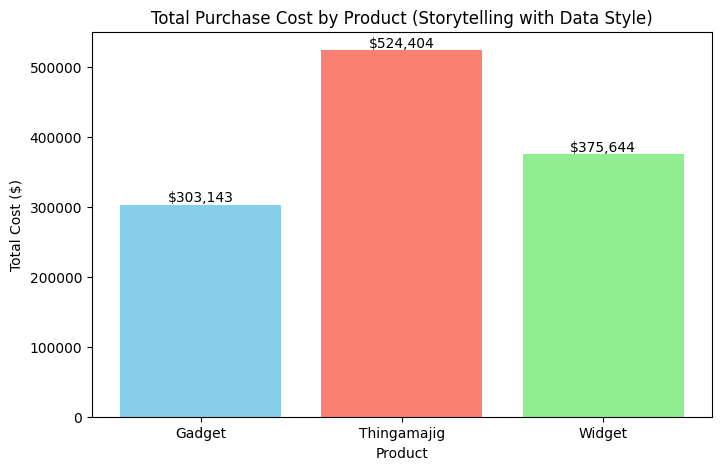

In [23]:
import matplotlib.pyplot as plt

# Sample data (from our purchase orders dataset)
product_totals = df.groupby("Product")["Total Cost"].sum()

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(product_totals.index, product_totals.values, color=['skyblue', 'salmon', 'lightgreen'])

# Add labels and title
plt.xlabel("Product")
plt.ylabel("Total Cost ($)")
plt.title("Total Purchase Cost by Product (Storytelling with Data Style)")

# Add value labels on top of bars
for i, value in enumerate(product_totals.values):
    plt.text(i, value + 50, f"${int(value):,}", ha='center', va='bottom')

# Show chart
plt.show()
